<a href="https://colab.research.google.com/github/SalvarezJ/Crib-Sentry/blob/main/notebooks/05_train_crib.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Crib Sentry: Crib Detector Training
In this notebook I train a detector that finds only the crib. I use Crib_detection and the Crib boxes from Baby in Crib.

In [ ]:
!pip install -q ultralytics roboflow

from google.colab import drive, userdata
drive.mount('/content/drive')

from roboflow import Roboflow
rf = Roboflow(api_key=userdata.get('ROBOFLOW_API_KEY'))
crib_data = rf.workspace("internship-cqxlp").project("crib_detection-xgv9n").version(1).download("yolov11")

print(crib_data.location)
!cat {crib_data.location}/data.yaml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 336.8/336.8 kB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 110.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.0/96.0 kB 9.5 MB/s eta 0:00:00
Mounted at /content/drive
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Crib_detection-1 in yolov11:: 100%|██████████| 2992/2992 [00:00<00:00, 5995.78it/s]


/content/Crib_detection-1
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 1
names: ['crib']

roboflow:
  workspace: internship-cqxlp
  project: crib_detection-xgv9n
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/internship-cqxlp/crib_detection-xgv9n/dataset/1

## Count the images and the labels
All labels in Crib_detection are outlines, and my detector needs boxes.

In [ ]:
import glob, os

for split in ['train', 'valid', 'test']:
    images = glob.glob(f'{crib_data.location}/{split}/images/*')
    print(split, len(images))

classes = set()
boxes = 0
outlines = 0
empty = 0
for f in glob.glob(f'{crib_data.location}/*/labels/*.txt'):
    lines = open(f).read().strip().splitlines()
    if len(lines) == 0:
        empty += 1
    for line in lines:
        parts = line.split()
        classes.add(parts[0])
        if len(parts) == 5:
            boxes += 1
        else:
            outlines += 1

print('classes:', classes)
print('boxes:', boxes, 'outlines:', outlines, 'empty label files:', empty)

for f in sorted(glob.glob(f'{crib_data.location}/train/images/*'))[:10]:
    print(os.path.basename(f))

train 1265
valid 229
test 0
classes: {'0'}
boxes: 0 outlines: 1569 empty label files: 41
00JC7QNDOKUW_jpg.rf.99a43498b6934e23d6076844062ec0d4.jpg
00TCBYQIU11O_aug_jpg.rf.fcf61f58171118eec554ed4f55889080.jpg
00TCBYQIU11O_jpg.rf.fd35638960e1ec713f70ca6cd93974d9.jpg
02BRU1RFK0GK_aug_jpg.rf.b72955b07625208f843f8514b0097740.jpg
02BRU1RFK0GK_jpg.rf.e6a54345f88d5d65dc0266cdb71dc07a.jpg
02FRVRCHOPYR_aug_jpg.rf.8850207397129b0f885d265c10955159.jpg
02FRVRCHOPYR_jpg.rf.8953b0f91edc6d2fd29404b2fd370f88.jpg
034CIRIJ82N4_jpg.rf.204341185076d08db522bc46e4f896ac.jpg
034KUK0IW69G_jpg.rf.2cdc10646e4caaf44b5a0166d4e97241.jpg
03P2CGB9VBH8_aug_jpg.rf.ae2f087fec021fe1c39f7e05ff673de2.jpg


## Find copies in the two folders
I look for an original image in training that has its copy in validation.

In [ ]:
import re

def base_id(path):
    name = os.path.basename(path).split('.rf.')[0]
    return re.sub(r'(_aug)?_(jpg|jpeg|png)$', '', name)

train_ids = set(base_id(f) for f in glob.glob(f'{crib_data.location}/train/images/*'))
valid_ids = set(base_id(f) for f in glob.glob(f'{crib_data.location}/valid/images/*'))
both = train_ids & valid_ids

print('different images in train:', len(train_ids))
print('different images in valid:', len(valid_ids))
print('in both folders:', len(both))

different images in train: 999
different images in valid: 223
in both folders: 101


## Make the crib folder with boxes
I move the 101 copies to training and change each outline into a box.

In [ ]:
import shutil

out = '/content/crib'
moved = 0
for split in ['train', 'valid']:
    for img in glob.glob(f'{crib_data.location}/{split}/images/*'):
        target = split
        if split == 'valid' and base_id(img) in both:
            target = 'train'
            moved += 1
        os.makedirs(f'{out}/{target}/images', exist_ok=True)
        os.makedirs(f'{out}/{target}/labels', exist_ok=True)

        name = 'CD_' + os.path.basename(img)
        shutil.copy(img, f'{out}/{target}/images/{name}')

        label = img.replace('/images/', '/labels/').rsplit('.', 1)[0] + '.txt'
        new_lines = []
        for line in open(label).read().strip().splitlines():
            nums = [float(n) for n in line.split()[1:]]
            xs = nums[0::2]
            ys = nums[1::2]
            x1, x2, y1, y2 = min(xs), max(xs), min(ys), max(ys)
            new_lines.append(f'0 {(x1+x2)/2} {(y1+y2)/2} {x2-x1} {y2-y1}')
        new_label = f'{out}/{target}/labels/' + name.rsplit('.', 1)[0] + '.txt'
        open(new_label, 'w').write('\n'.join(new_lines))

print('moved to train:', moved)

moved to train: 101


In [ ]:
for split in ['train', 'valid']:
    print(split, len(glob.glob(f'{out}/{split}/images/*')), 'images',
          len(glob.glob(f'{out}/{split}/labels/*')), 'label files')

train 1366 images 1366 label files
valid 128 images 128 label files


## Check the boxes
I look at 24 images to make sure that each box is on the crib.

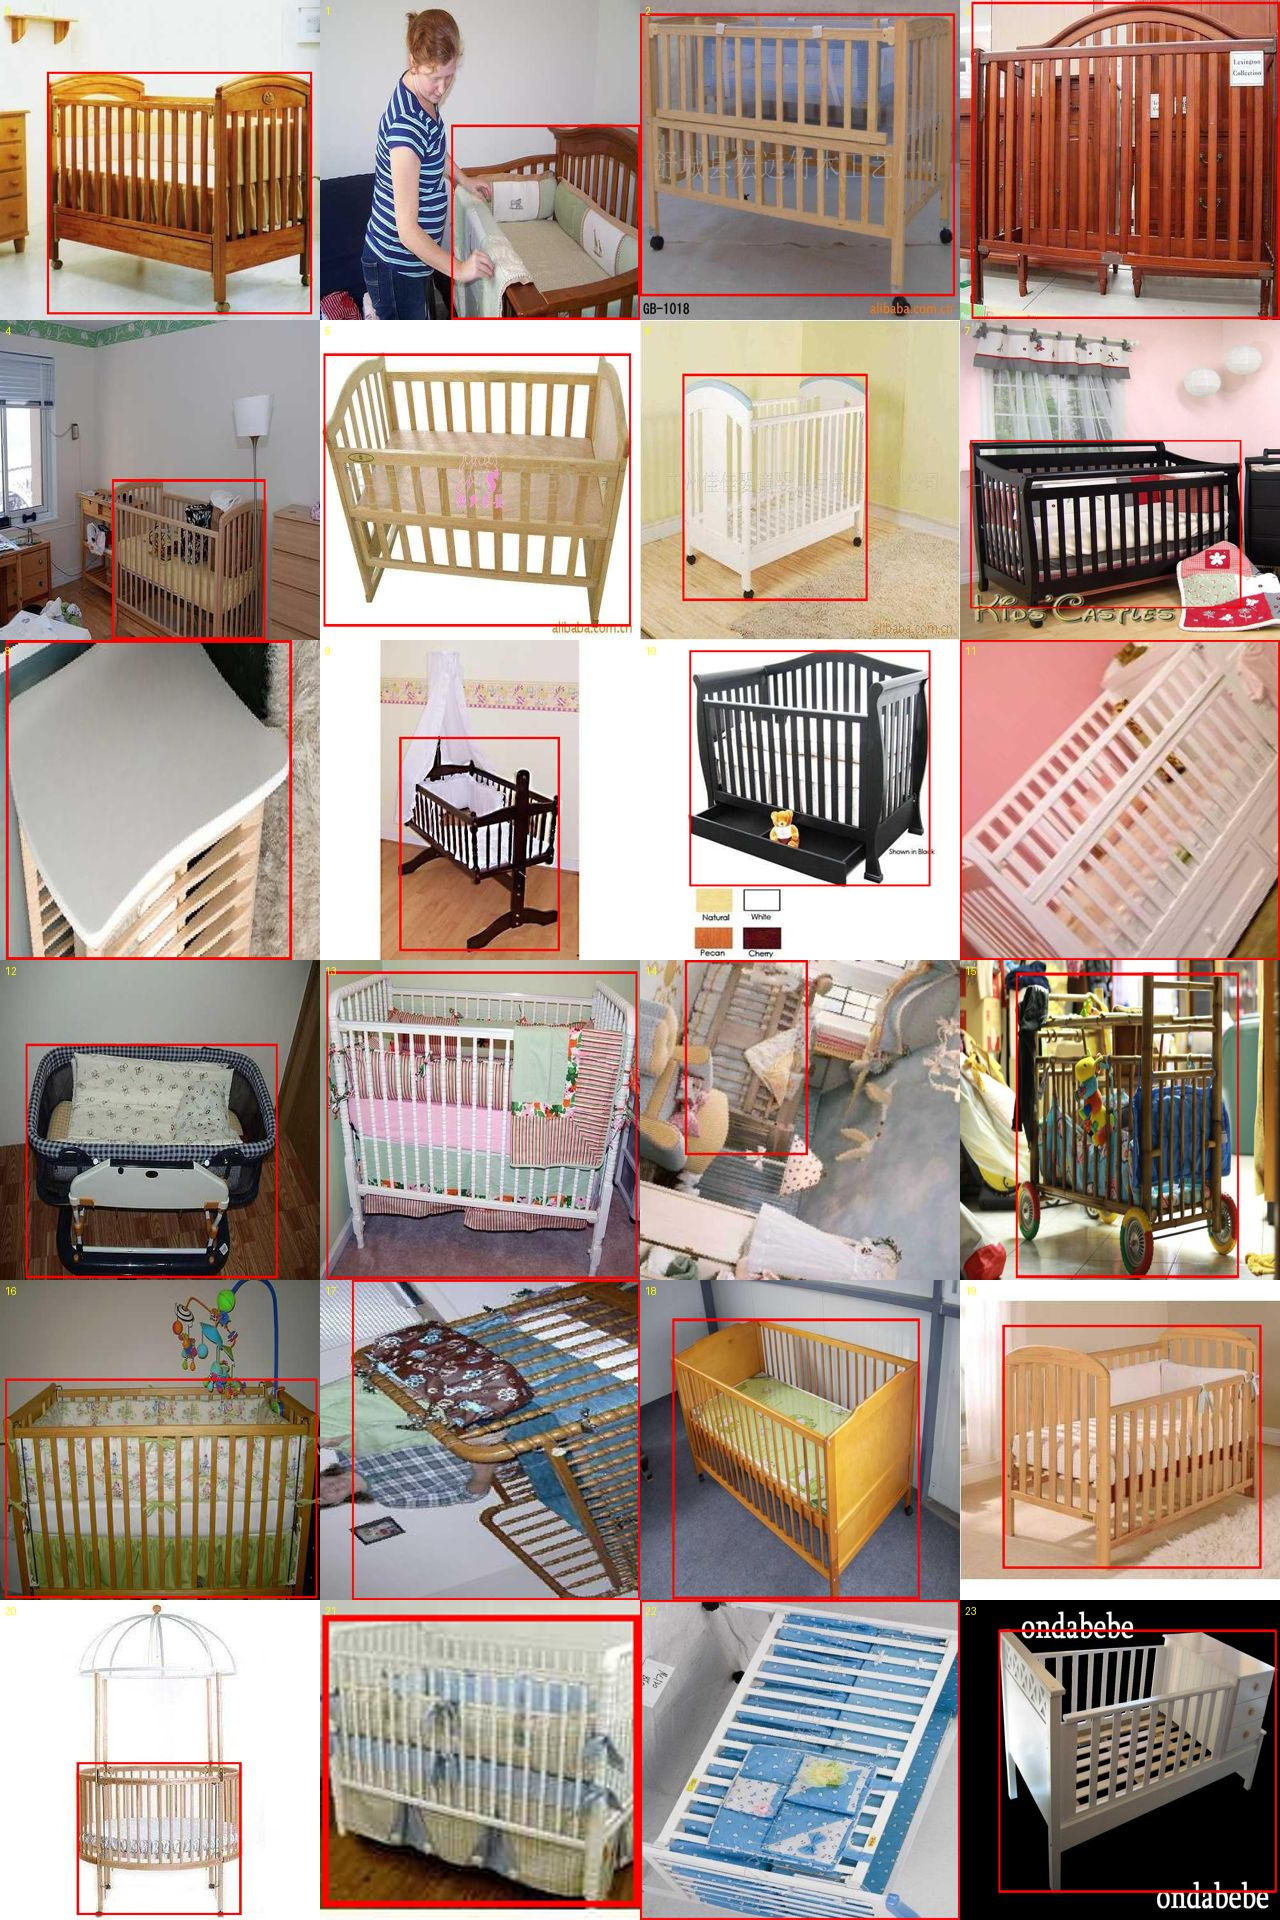

In [ ]:
import random
from PIL import Image as PILImage, ImageDraw
from IPython.display import Image, display

def sheet(paths, file, size=320, cols=4):
    rows = (len(paths) + cols - 1) // cols
    page = PILImage.new('RGB', (cols * size, rows * size), 'white')
    for i, p in enumerate(paths):
        im = PILImage.open(p).convert('RGB')
        w, h = im.size
        draw = ImageDraw.Draw(im)
        label = p.replace('/images/', '/labels/').rsplit('.', 1)[0] + '.txt'
        for line in open(label).read().strip().splitlines():
            c, x, y, bw, bh = [float(n) for n in line.split()]
            draw.rectangle([(x - bw/2) * w, (y - bh/2) * h, (x + bw/2) * w, (y + bh/2) * h],
                           outline='red', width=max(3, w // 150))
        im = im.resize((size, size))
        ImageDraw.Draw(im).text((5, 5), str(i), fill='yellow')
        page.paste(im, ((i % cols) * size, (i // cols) * size))
    page.save(file, quality=80)
    display(Image(filename=file))

random.seed(0)
sample = random.sample(sorted(glob.glob(f'{out}/train/images/*')), 24)
sheet(sample, '/content/crib_sample.jpg')

## Add Baby in Crib
I keep only the Crib boxes from Baby in Crib. I do not use its test folder, because those 24 images are my test.

In [ ]:
bic = rf.workspace("test-1caua").project("baby-in-crib").version(1).download("yolov11")
!cat {bic.location}/data.yaml

for split in ['train', 'valid']:
    with_crib = 0
    files = glob.glob(f'{bic.location}/{split}/labels/*.txt')
    for f in files:
        for line in open(f).read().strip().splitlines():
            if line.split()[0] == '1':
                with_crib += 1
                break
    print(split, len(files), 'images,', with_crib, 'with a crib label')

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Baby-in-Crib-1 in yolov11:: 100%|██████████| 496/496 [00:00<00:00, 6494.41it/s]


train: ../train/images
val: ../valid/images
test: ../test/images

nc: 2
names: ['Child', 'Crib']

roboflow:
  workspace: test-1caua
  project: baby-in-crib
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/test-1caua/baby-in-crib/dataset/1train 169 images, 112 with a crib label
valid 49 images, 32 with a crib label


train 1535 images 1535 label files
valid 177 images 177 label files


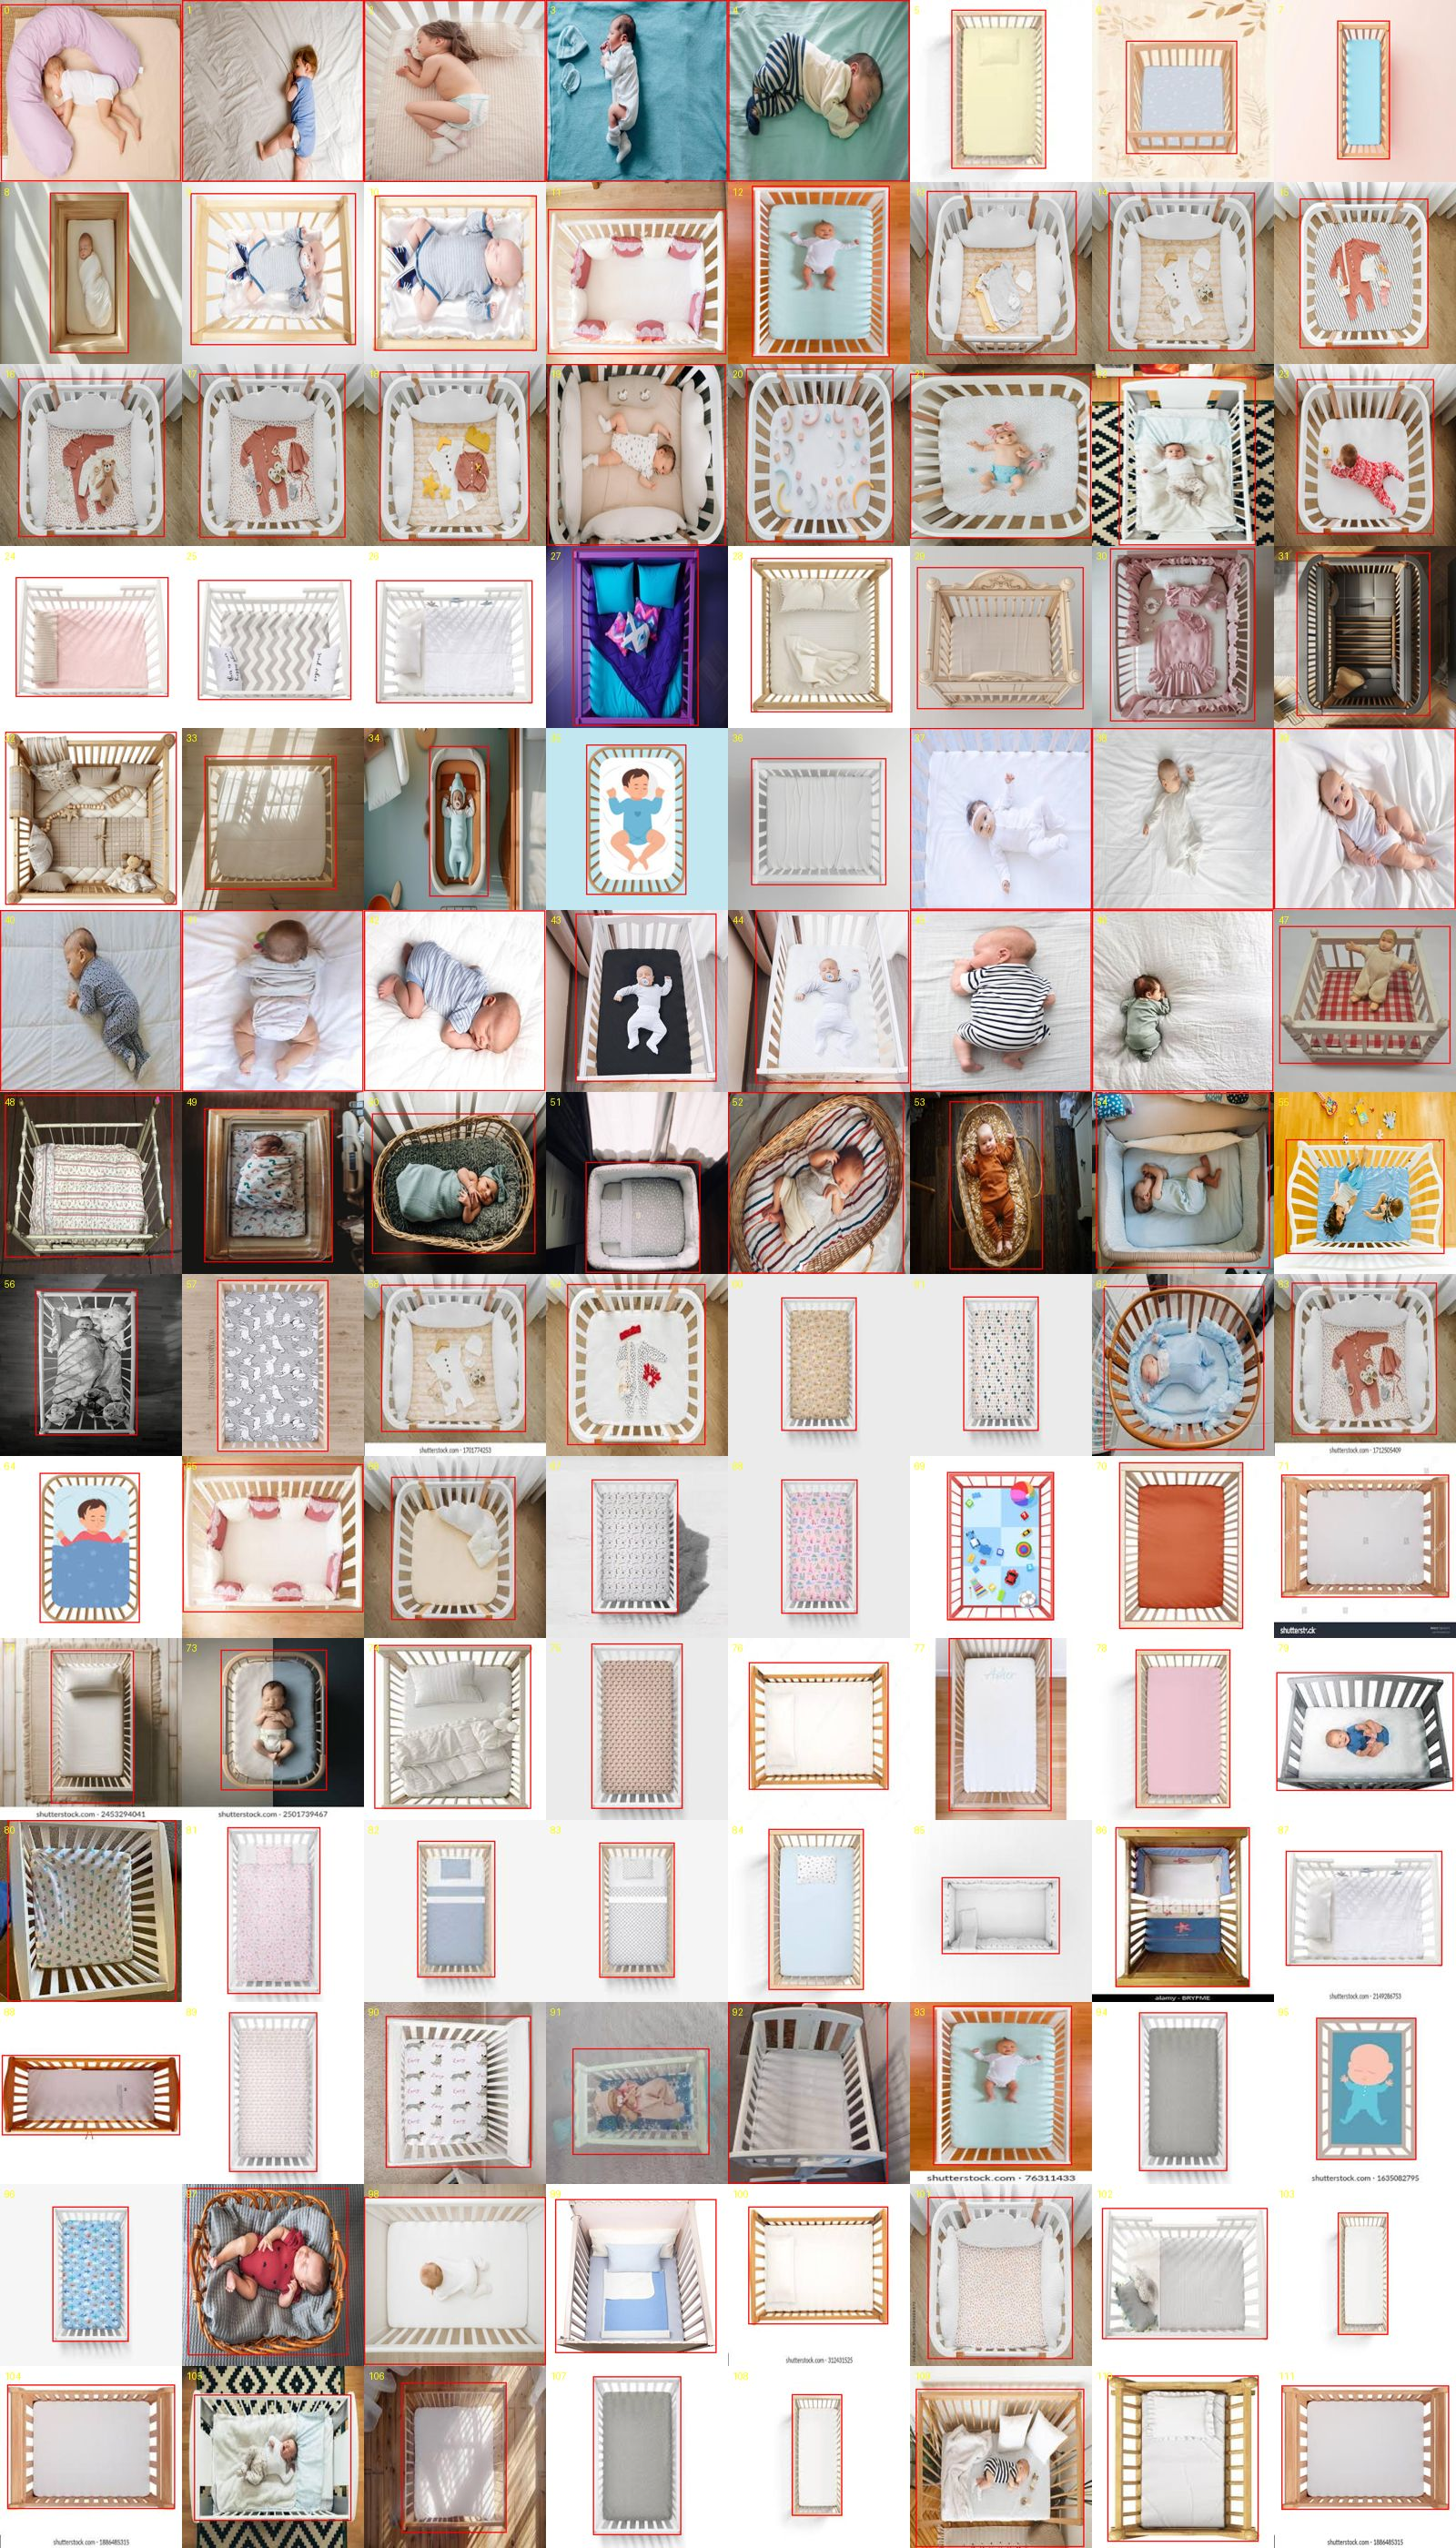

In [ ]:
bc_with_crib = []
for split in ['train', 'valid']:
    for img in glob.glob(f'{bic.location}/{split}/images/*'):
        name = 'BC_' + os.path.basename(img)
        new_img = f'{out}/{split}/images/{name}'
        shutil.copy(img, new_img)

        label = img.replace('/images/', '/labels/').rsplit('.', 1)[0] + '.txt'
        new_lines = []
        for line in open(label).read().strip().splitlines():
            parts = line.split()
            if parts[0] != '1':
                continue
            nums = [float(n) for n in parts[1:]]
            if len(nums) > 4:
                xs = nums[0::2]
                ys = nums[1::2]
                x1, x2, y1, y2 = min(xs), max(xs), min(ys), max(ys)
                nums = [(x1+x2)/2, (y1+y2)/2, x2-x1, y2-y1]
            new_lines.append(f'0 {nums[0]} {nums[1]} {nums[2]} {nums[3]}')
        new_label = f'{out}/{split}/labels/' + name.rsplit('.', 1)[0] + '.txt'
        open(new_label, 'w').write('\n'.join(new_lines))
        if new_lines and split == 'train':
            bc_with_crib.append(new_img)

for split in ['train', 'valid']:
    print(split, len(glob.glob(f'{out}/{split}/images/*')), 'images',
          len(glob.glob(f'{out}/{split}/labels/*')), 'label files')

sheet(sorted(bc_with_crib), '/content/bic_cribs.jpg', size=200, cols=8)

## Remove the wrong crib labels
Baby in Crib has crib boxes on photos that show a baby with no crib. I remove 11 of these labels from training and 7 from validation.

In [ ]:
wrong = [0, 1, 3, 4, 38, 39, 40, 41, 42, 45, 46]
pages = sorted(bc_with_crib)
for i in wrong:
    label = pages[i].replace('/images/', '/labels/').rsplit('.', 1)[0] + '.txt'
    open(label, 'w').write('')
print('labels removed:', len(wrong))

labels removed: 11


validation images with a crib label: 32


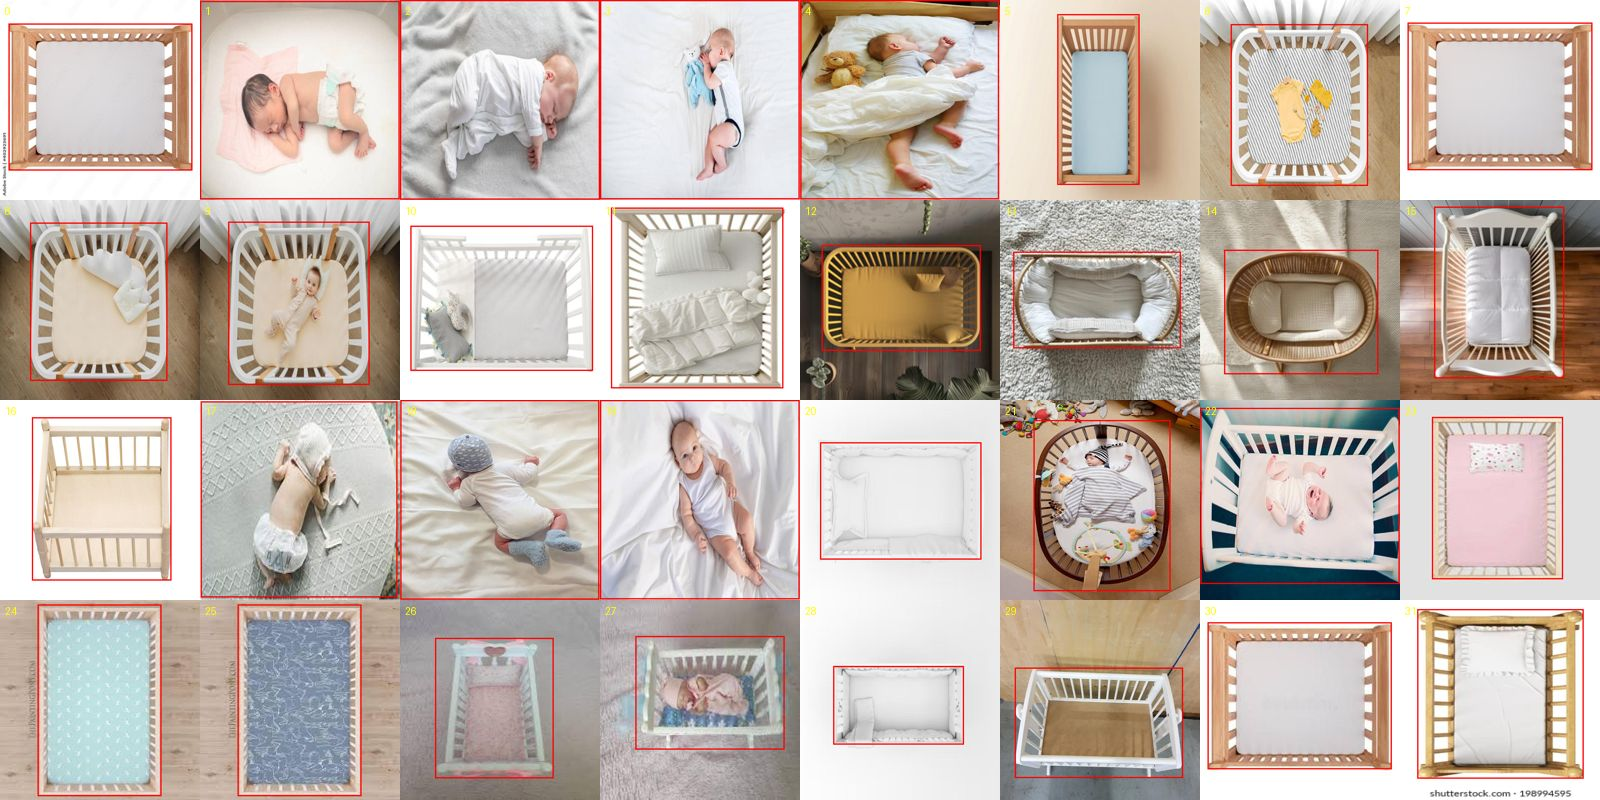

In [ ]:
bc_valid = []
for img in sorted(glob.glob(f'{out}/valid/images/BC_*')):
    label = img.replace('/images/', '/labels/').rsplit('.', 1)[0] + '.txt'
    if open(label).read().strip():
        bc_valid.append(img)

print('validation images with a crib label:', len(bc_valid))
sheet(bc_valid, '/content/bic_valid.jpg', size=200, cols=8)

In [ ]:
wrong_valid = [1, 2, 3, 4, 17, 18, 19]
for i in wrong_valid:
    label = bc_valid[i].replace('/images/', '/labels/').rsplit('.', 1)[0] + '.txt'
    open(label, 'w').write('')
print('labels removed:', len(wrong_valid))

labels removed: 7


## Train
I use the same training settings as in notebook 02, so only the data is different.

In [ ]:
yaml_text = f"""path: {out}
train: train/images
val: valid/images
nc: 1
names: ['crib']
"""
open(f'{out}/data.yaml', 'w').write(yaml_text)

import albumentations as A
from ultralytics import YOLO

model = YOLO('yolo11n.pt')
results = model.train(
    data=f'{out}/data.yaml',
    epochs=50, imgsz=640, batch=16,
    hsv_v=0.6, degrees=15,
    augmentations=[A.Blur(blur_limit=7, p=0.3)],
    project='/content/drive/MyDrive/crib_sentry_v2',
    name='crib')

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics 8.4.173 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, augmentations=[{'__version__': '2.0.8', 'transform': {'__class_fullname__': 'Blur', 'p': 0.3, 'blur_limit': (3, 7)}}], auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/crib/data.yaml, degrees=15, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False

## Results
On 177 validation images: precision 0.944, recall 0.850, mAP50 0.908, mAP50-95 0.774.
These images are like the training images. The test images in notebook 07 give the real result.